# The Physical Basis for Ocean Color Products

## Motivation

Ocean color products are generated using visible and near-infrared measurements to infer properties of the upper ocean. The most common product is chlorophyll-a concentration, which is often used as an indicator of phytoplankton biomass, although there are several other products that can be derived from ocean color measurements.

Ocean color observations are useful because phytoplankton form the base of many marine food webs and play an important role in the global carbon cycle. However, ocean color products require careful interpretation because satellites do not directly measure chlorophyll-a. Instead, they measures radiance leaving the ocean-atmosphere system. In this notebook, we will consider the relationship between chlorophyll-a and observed radiances, and how this relationship is leveraged to forms algorithms for ocean color products.

### Some Key Questions for Consideration

In this notebook, we will consider the following questions:

- What happens to sunlight when it reaches the ocean surface?
- How do absorption and scattering determine the color of the ocean?
- Why is chlorophyll-a visible to satellites?
- What are the main limitations of ocean color observations?

**Modules for this notebook**

In this notebook, we'll take a look at a few plots to help our understanding. Here, we'll import some Python modules to aid in our plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, LogNorm

In addition, we will be plotting a few figures showing differences between seawater with a range of chlorophyll-a concentrations that appear on a scale from blue to green. To help in our understanding of these plots, let's also define a blue-green colorbar for use below:

In [2]:
water_color = "#1f77b4"
chla_color = "#2ca02c"

blue_green_cmap = LinearSegmentedColormap.from_list(
    "blue_green",
    [water_color, chla_color]
)
norm = LogNorm(vmin=0.001, vmax=100)

## Electromagnetic Radiation at the Ocean Surface

When electromagnetic radition from the sun reaches the ocean, several things happen to the incident light:

1. Some light is **directly reflected** from the surface.
2. Some light is **transmitted** into the water column.
3. Within the water column, light can be **absorbed** or **scattered**.
4. A small fraction of scattered light exits the ocean and travels upward toward the satellite.

The upward signal that exits the ocean is called **water-leaving radiance**. Ocean color algorithms are designed to isolate this water-leaving signal from other contributions such as atmospheric scattering, surface reflection, and sunglint.

### Sunglint and Surface Reflection

Sunglint occurs when sunlight reflects off the ocean surface toward the satellite sensor. Glint can overwhelm the water-leaving radiance signal, especially when the position of the satellite relative to the sun causes a reflection into the satellite field of view or the ocean surface is rough. The following image shows some examples of sun glint in MODIS imagery:

```{figure} ../images/ocean_color/modis_sunglint.jpeg
---
height: 300px
name: modis-sunglint
---
Example of sun glint visible in scenes from the MODIS sensor on NASA's Aqua satellite. Image from the NASA [Science of Sunglint](https://science.nasa.gov/earth/earth-observatory/the-science-of-sunglint-84333/) page.
```

Because ocean color retrievals rely on a small signal leaving the water column, sunglint and clouds are commonly masked from higher-level ocean color products.

### Absorption by Water

Liquid water absorbs long visible wavelengths more strongly than short visible wavelengths. Red light is absorbed efficiently, while blue light penetrates farther into clear water - this fact is intuitive for divers who are familiar with the blue-green appearance of the ocean envionment on deeper dives. Infrared radiation is absorbed extremely close to the surface, which is why infrared observations are useful for sea surface temperature but not for observing subsurface ocean color or temperature (see next section).

The figure below shows the absorption of pure water in both linear and logarithmic scales:

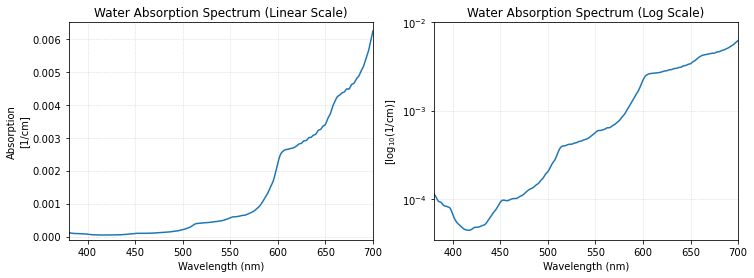

In [3]:
# read in the spectrum
water_spectrum = np.genfromtxt('../data/ocean_color/water_absorption_spectrum.csv',delimiter=',')

# make a plot
fig = plt.figure(figsize=(12,4))

# linear scale
plt.subplot(1,2,1)
plt.plot(water_spectrum[:,0], water_spectrum[:,1], color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorption\n[1/cm]')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Water Absorption Spectrum (Linear Scale)')
plt.gca().set_xlim([380,700])
plt.gca().set_ylim([-0.0001,0.0065])

# log scale
plt.subplot(1,2,2)
plt.plot(water_spectrum[:,0], np.log10(water_spectrum[:,1]), color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('[log$_{10}$(1/cm)]')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Water Absorption Spectrum (Log Scale)')
plt.gca().set_xlim([380,700])
plt.gca().set_yticks([-4, -3, -2], ['10$^{-4}$', '10$^{-3}$', '10$^{-2}$'])

plt.show()

As we can see in the figure above, light at longer wavelengths (e.g. red) absorbs much stronger than wavelengths in the blue-green component of the spectrum. This turns out to be quite advantageous for examining green-colored pigments in the water column, like chlorophyll-a!

### Scattering by Water

The color of the ocean observed by a satellite also depends on scattering. In clear open-ocean water, blue wavelengths are scattered efficiently. This scattering is similar to the Rayleigh scattering in the atmosphere discussed in the Fundamentals section and also has an inverse 4$^{th}$ root dependence with wavelength. Like the sky, this scattering is the same reasion that the ocean appears blue. More information about this scattering can be found in [Zhang et al 2009](https://doi.org/10.1364/OE.17.001671).

The scattering can be visualized with an idealized curve as shown below:

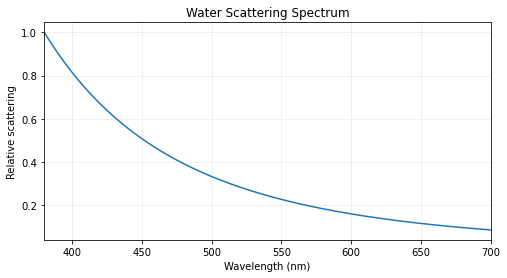

In [4]:
# construct an idealized water scattering spectrum 
wavelength = water_spectrum[:,0]
water_scattering = (550 / wavelength) ** 4
water_scattering = water_scattering / water_scattering.max()

plt.figure(figsize=(8,4))
plt.plot(wavelength, water_scattering, color=water_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative scattering')
plt.title('Water Scattering Spectrum')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.gca().set_xlim([380,700])
plt.show()

### Remote-Sensing Reflectance

A common quantity for ocean color is the *remote-sensing reflectance* - the ratio of light reflected from a surface to the light incident on the surface. This is written as:

$$R_{rs} = \frac{L_w}{E_d}$$

where:

- $R_{rs}$ is remote-sensing reflectance 
- $L_w$ is water-leaving radiance.
- $E_d$ is downwelling irradiance.

Note that each term is a function of the wavelength $\lambda$.

We can compute this for water using the absorption and scattering curves shown above:

In [5]:
# gather absorption from the water spectrum
absorption = water_spectrum[:,1]

# Pure-water-like backscatter
scattering_factor = 5e-5
scattering = scattering_factor * water_scattering

# compute remote sensing reflectance
Rrs_water = scattering / (absorption + scattering)

Let's see what this looks like:

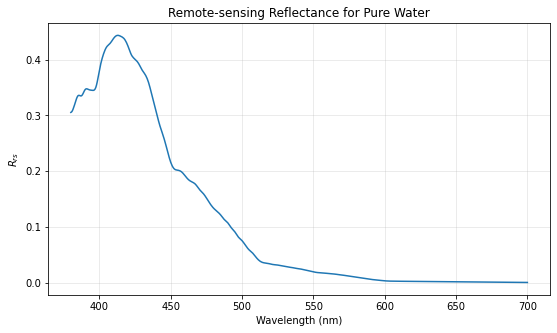

In [6]:
plt.figure(figsize=(9, 5))

# plot the Rrs for water
plt.plot(water_spectrum[:,0], Rrs_water, color=water_color)

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$R_{rs}$")
plt.title("Remote-sensing Reflectance for Pure Water")
plt.grid(True, alpha=0.3)
plt.show()

As we can see, water has the highest reflectance in the blue region of the visible spectrum. Up next, we'll consider how the presence of chlorophyll-a modulates this quantity across the visible spectrum.

## Phytoplankton and Chlorophyll-a

Phytoplankton are drifting photosynthetic organisms that form the base of the marine food web. Nearly all phytoplankton contain **chlorophyll-a**, a pigment used in photosynthesis.

### Absorption by Chlorophyll-a

Chlorophyll-a absorbs strongly in the blue part of the visible spectrum and reflects or scatters more green light. Let's take a look at the spectrum:

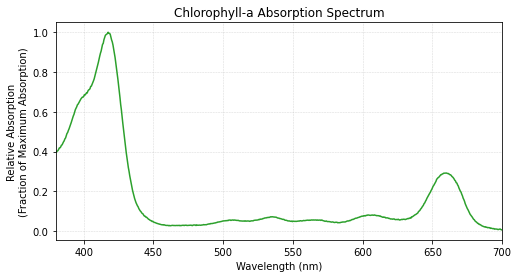

In [7]:
# read in the spectrum
chla_spectrum = np.genfromtxt('../data/ocean_color/chl_absorption_spectrum.csv', delimiter=',')
chla_spectrum[:,1] *= 1/np.max(chla_spectrum[:,1])

# make a plot
fig = plt.figure(figsize=(8,4))
plt.plot(chla_spectrum[:,0], chla_spectrum[:,1], color=chla_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative Absorption\n(Fraction of Maximum Absorption)')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Chlorophyll-a Absorption Spectrum')
plt.gca().set_xlim([380,700])
plt.show()

Here, we can see that there is strong absorption in the 400-450 nm range - the range that absorption by water is low. There is also a smaller but still significant peak in the 650-680 nm range.

### Scattering by Chlorophyll-a

Just like water, chlorophyll-a also scatters light preferentially in the visible spectrum with higher scattering at smaller wavelengths. Let's take a look at an analgous scattering curve for chlorophyll-a.

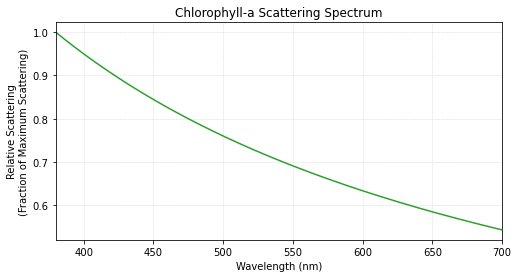

In [8]:
# compute scattering due to chlorophyll
chl_scattering = (550 / wavelength)
chl_scattering *= 1/np.max(chl_scattering)

# make a plot
fig = plt.figure(figsize=(8,4))
plt.plot(chla_spectrum[:,0], chl_scattering, color=chla_color)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative Scattering\n(Fraction of Maximum Scattering)')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.title('Chlorophyll-a Scattering Spectrum')
plt.gca().set_xlim([380,700])
plt.show()

As we can see, the chlorophyll-a scattering spectrum looks somewhat similar to the water spectrum, but it has an inverse linear dependence on wavelength, rather than an inverse 4th order dependence.

### Remote Sensing Reflectance of Chlorophyll-a in Water

When chlorophyll-a is present in water, the absorbance and scattering properties seen above change the shape of the spectrum of water-leaving radiance and therefore the remote sensing reflectance. The absorption and scattering are additive but the computation is similar at that for water. Let's bundle this into a function we can use for different chlorophyll-a concentrations:

In [9]:
def compute_rrs(chl):

    # compute absorption as the sum of water and chlorophyll components
    chl_scale_factor = 0.005
    absorption = water_spectrum[:,1] + chl * chl_scale_factor  * chla_spectrum[:,1]

    # Pure-water-like backscatter
    water_scattering_factor = 5e-5
    water_scattering = water_scattering_factor * (550 / wavelength) ** 4

    # Particle backscatter associated with chlorophyll-a
    chla_scattering_factor = 3e-5 * chl**0.62
    chl_scattering = chla_scattering_factor * (550 / wavelength)

    # Total scattering
    scattering = water_scattering + chl_scattering

    # compute remote sensing reflectance
    Rrs = scattering / (absorption + scattering)
    
    return Rrs

Using this function, let's take a look at how different values for chlorophyll-a modulate the water spectra:

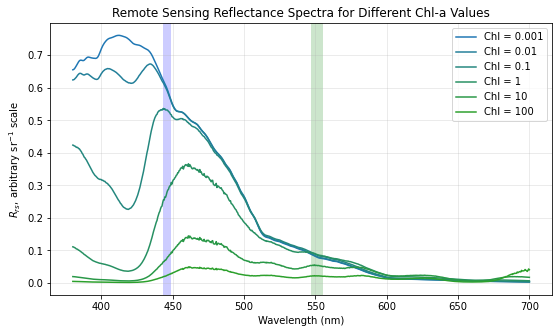

In [10]:
plt.figure(figsize=(9, 5))

chl_values = [0.001, 0.01, 0.1, 1, 10, 100]

for chl in chl_values:
    rrs = compute_rrs(chl)
    color = blue_green_cmap(norm(chl))
    plt.plot(water_spectrum[:,0], rrs, color=color, label=f"Chl = {chl:g}")
y_min, y_max = plt.ylim()
plt.gca().add_patch(Rectangle( (443,y_min), 449-443, y_max-y_min, facecolor='blue', alpha=0.2))
plt.gca().add_patch(Rectangle( (547,y_min), 555-547, y_max-y_min, facecolor='green', alpha=0.2))
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$R_{rs}$, arbitrary sr$^{-1}$ scale")
plt.title("Remote Sensing Reflectance Spectra for Different Chl-a Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


We can see from this plot that the chlorophyll-a concentration increases, the dominant color of water-leaving radiance shifts from blue toward green. This shift is the basis for many empirical satellite chlorophyll-a algorithms.

### Ratios of Reflectances Between Green and Blue Bands

In the above figure, there are two vertical bars in the blue and green parts of the visible spectrum are the typical wavelengths where optical satellites are designed to observe these colors. In these bands, we can see that for most chlorophyll-a concentrations, the blue $R_{rs}$ values are higher than green. However, we can compare the the ratio of the values through different values:

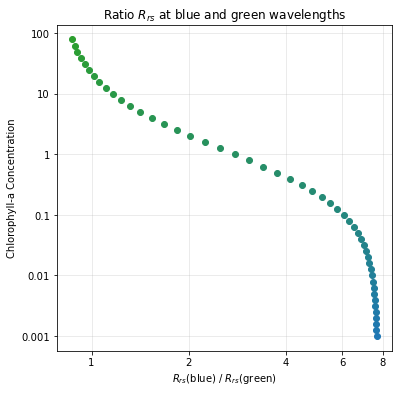

In [11]:
plt.figure(figsize=(6, 6))

# determine indices for the blue and green parts of the spectrum
blue_index = np.argmin(np.abs(water_spectrum[:,0]-443))
green_index = np.argmin(np.abs(water_spectrum[:,0]-550))

# compute chl values
chl_values = 10**np.arange(-3,2,0.1)

# compute and plot Rrs at a range of chl values
for chl in chl_values:
    rrs = compute_rrs(chl)
    color = blue_green_cmap(norm(chl))
    rrs_green = rrs[green_index]
    rrs_blue = rrs[blue_index]
    X = np.log10(rrs_blue/rrs_green)
    plt.plot(X, np.log10(chl), 'o', color=color, label=f"Chl = {chl:g}")

plt.xticks([0,np.log10(2),np.log10(4),np.log10(6),np.log10(8)], [1,2,4,6,8])
plt.xlabel('$R_{rs}$(blue) / $R_{rs}$(green)')
    
plt.yticks([-3, -2, -1, 0, 1, 2], [0.001, 0.01, 0.1, 1, 10, 100])
plt.ylabel('Chlorophyll-a Concentration')
plt.grid(True, alpha=0.3)

plt.title('Ratio $R_{rs}$ at blue and green wavelengths')
plt.show()

As we can see, there is a clear relationship linking satellite-observable properties (the remote sensing reflectances) and the chlorophyll-a concentration - this is the foundation of ocean color algorithms for chlorophyll-a estimates! As a result, empirical chlorophyll-a algorithms use ratios of blue and green reflectances because chlorophyll-a changes the relative amount of blue and green light leaving the ocean. We'll examine a general algorithm in a subsequent notebook.